In [1]:
import matplotlib.pyplot as plt
import numpy as np
from uncertainties import ufloat, ufloat_fromstr
from scipy.constants import c, h
from uncertainties.unumpy import nominal_values as values
from uncertainties.unumpy import std_devs as errors

In [2]:
#the F numbers of the enegy levels
Fs=np.array([2,1,2,3])

In [3]:
# the transition from steck in MHz
large=ufloat_fromstr("384.2304844685(62)e6")
HF=np.array([ufloat_fromstr("2.563005979089109(34)e3"),-ufloat_fromstr("229.8518(56)"),ufloat_fromstr("72.9112(32)"),ufloat_fromstr("193.7407(46)")])

In [4]:
#lande gf factors
gFs=np.array([1/2,2/3,2/3,2/3])


In [5]:
#bohr magnetron in mHz per gauss
muB=ufloat_fromstr("1.39962449361(42)")

In [6]:
#returns the possible mF values for each F value in an array
def gen_mFs(F):
    return np.arange(-F,F+1)

In [7]:
Bzs=np.linspace(0,20,100) #magnetic feild strengths in gauss

In [8]:
DeltaEs=[]

for i in range(1,4):
    F=Fs[i]
    gF=gFs[i]
    for mF in gen_mFs(F):
        DeltaEs.append(muB*gF*mF*Bzs)



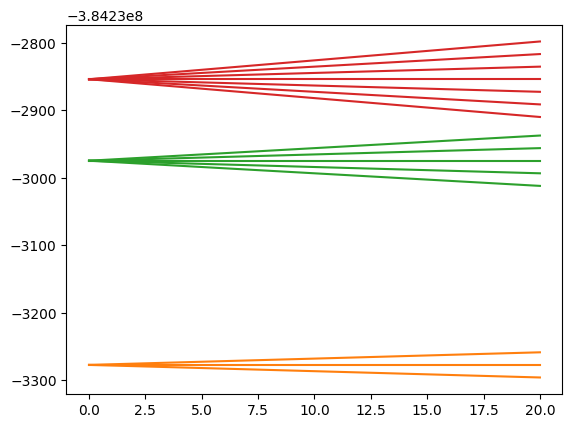

In [9]:
i=0
for j in range(1,4):
    F=Fs[j]
    for mF in gen_mFs(F):
        Es=DeltaEs[i]+HF[j]-large-HF[0]
        plt.plot(Bzs,values(Es),color=f'C{j}')
        i+=1

In [38]:
def transitions(F,gF,Fprimes,gFprimes):
    perturbations=[]
    for i,Fprime in enumerate(Fprimes):
        gFprime=gFprimes[i]
        for mF in range(-F,F+1):
            for mFprime in range(-Fprime,Fprime+1):
                if (mF==mFprime-1) or (mF==mFprime+1) or (mF==mFprime and F!=Fprime):
                    perturbation=(mFprime*gFprime-mF*gF)*muB
                    energy=HF[Fprime]-HF[0]+large
                    perturbations.append([F,mF,Fprime,mFprime,energy,perturbation])
    return np.array(perturbations)

    

In [39]:
transitions85=transitions(2,1/2,[1,2,3],[2/3,2/3,2/3])

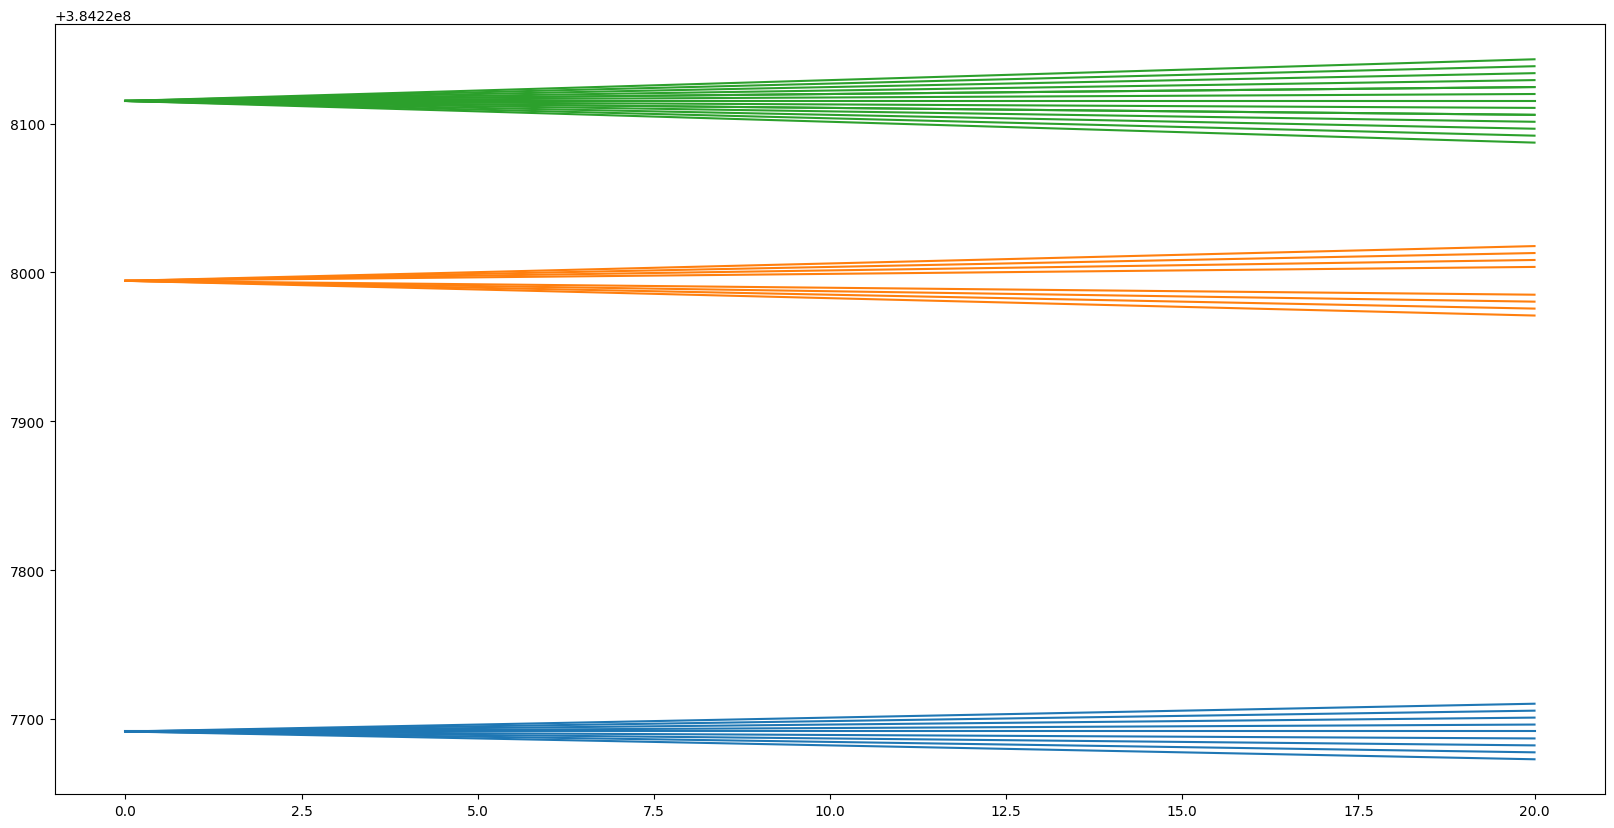

In [40]:
plt.figure(figsize=(20,10))
for transition in transitions85:
    plt.plot(Bzs,values(transition[5]*Bzs+transition[4]),color=f'C{transition[2]-1}')

In [61]:
def generate_crossover_peaks(transitions):
    crossovers=[]
    n_transitions=len(transitions)
    for i in range(n_transitions):
        for j in range(n_transitions):
            if i!=j:
                transition1=transitions85[i]
                transition2=transitions85[j]
                if np.all(transition1[[0,1]]==transition2[[0,1]]):
                   crossovers.append([*transition1[:4],*transition2[2:4],*(transition1[4:]+transition2[4:])/2])

    return np.array(crossovers)

In [65]:
print(transitions85[[0]])

[[2 -2 1 -1 384227691.6107209+/-0.008354639429682169
  0.46654149787000004+/-1.4e-10]]


In [63]:
crossovers85=generate_crossover_peaks(transitions85)

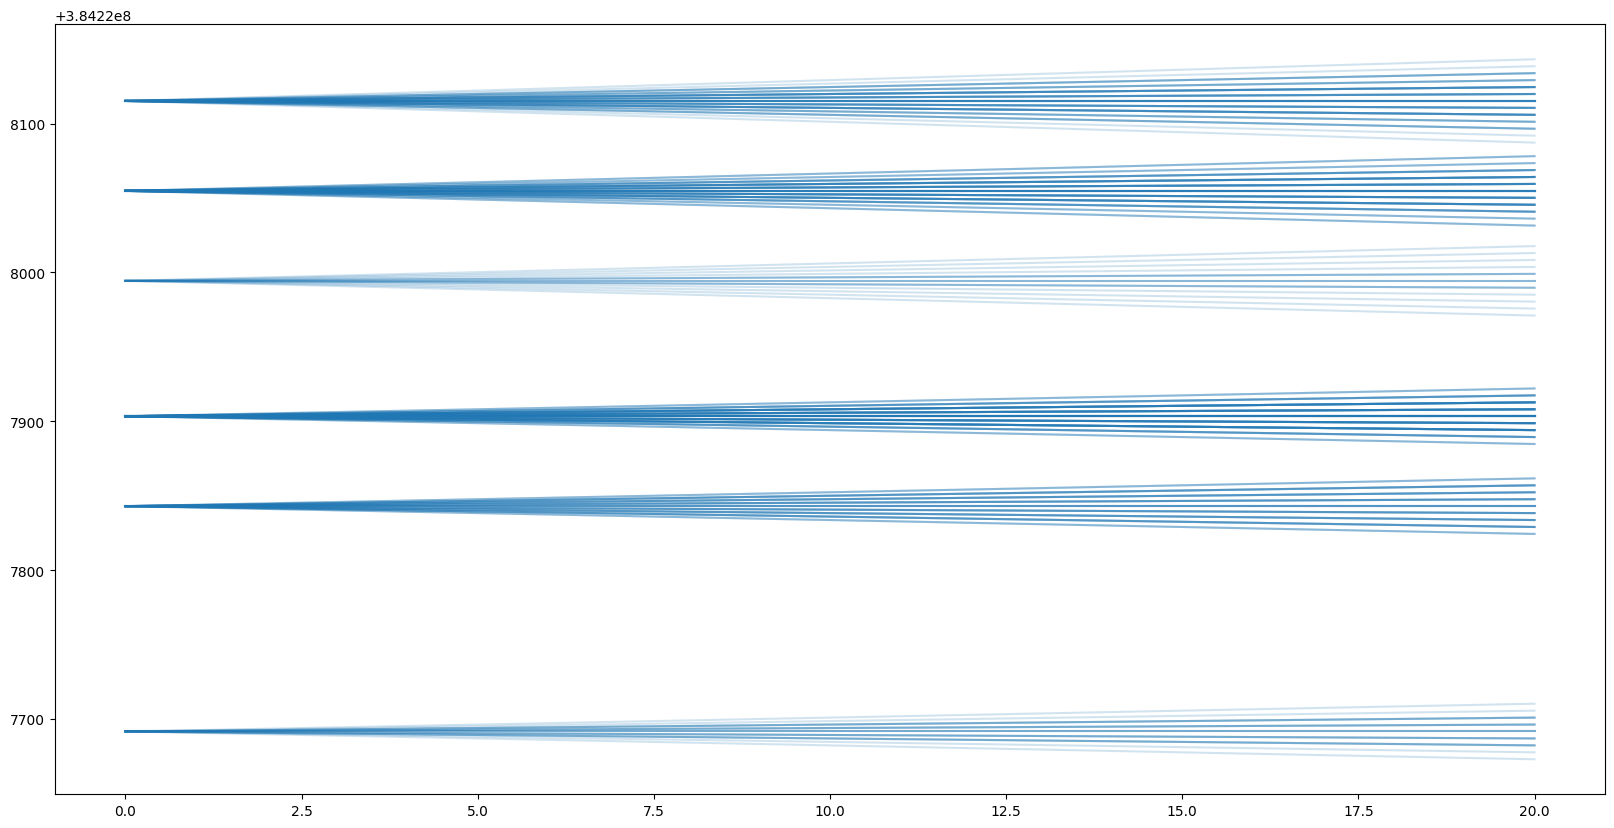

In [72]:
plt.figure(figsize=(20,10))
for transition in transitions85:
    plt.plot(Bzs,values(transition[5]*Bzs+transition[4]),color='C0',alpha=0.2)

for  crossover in crossovers85:
    plt.plot(Bzs,values(crossover[7]*Bzs+crossover[6]),color='C0',alpha=0.3)

In [74]:
def lorentz(x,A,x0,gamma):
    return A/(1+((x-x0)/gamma)**2)

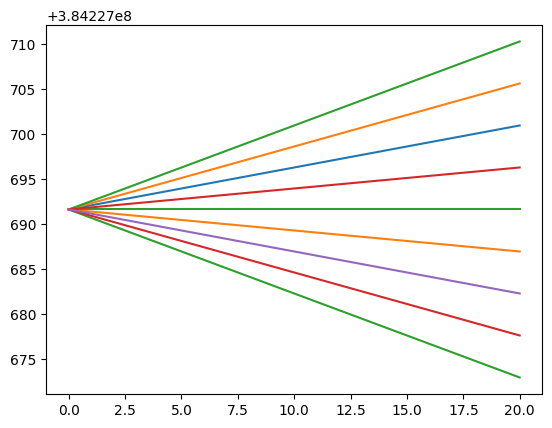

In [91]:
for transition in transitions85:
    if transition[2]==1:
        plt.plot(Bzs,values(transition[5]*Bzs+transition[4]),color=f'C{transition[1]+2}')

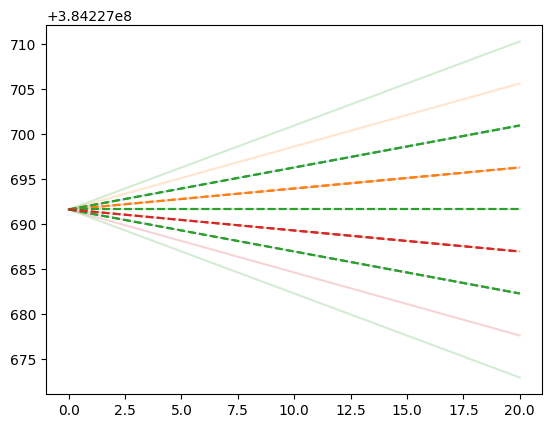

In [92]:
for transition in transitions85:
    if transition[2]==1:
        plt.plot(Bzs,values(transition[5]*Bzs+transition[4]),color=f'C{transition[1]+2}',alpha=0.2)

for crossover in crossovers85:
    if crossover[2]==1 and crossover[4]==1:
        plt.plot(Bzs,values(crossover[7]*Bzs+crossover[6]),color=f'C{crossover[1]+2}',linestyle='--')

In [97]:
def lorentz_ensamble(x,A,gamma,x0,muB,dxs):
    p=0
    for dx in dxs:
        p+=lorentz(x,A,x0+muB*dx,gamma)

    return p

In [106]:
xs=np.linspace(0,100,10000)

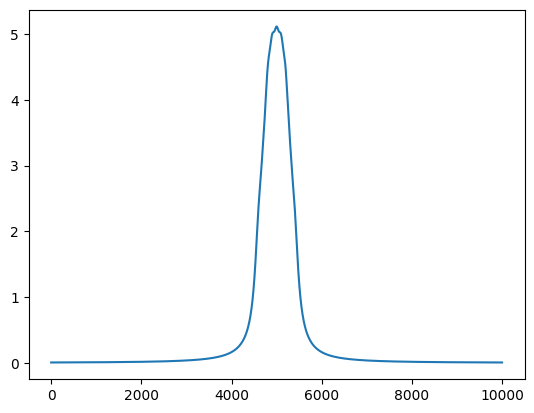

In [114]:
plt.plot(lorentz_ensamble(xs,1,1,50,1,[-4,-3,-2,-2,-1,-1,0,0,1,1,2,2,3,4]))